## Chapter 3

# Theory

1. Vad kännetecknar regressionsproblem? Ge några exempel på tillämpnings-
områden.

Continual dependant variables. Can for example be used to make future predictions, examples being for demand during production, or sales.

2. Förklara utvärderingsmåtten RMSE, MSE och MAE.

Root Mean Squared Error - Squares the error of all entries, then takes the mean, after which it takes the root of the mean to get a more human readable result, roughly counteracting the square of the errors taken. Produces exponential results, biasing further against larger errors.

Mean Squared Error - Same as RMSE, without taking the root of the mean, less human readable, but ranks the errors in the in the same way as RMSE.

Mean Absolute Error - Takes the mean of the absolute value of all errors, produces a linear correlation against the size of the error.

3. Om vi ska rangordna olika modeller, spelar det någon roll om RMSE eller
MSE används? Varför?

As discussed prior, RMSE produces an exponentially larger result, given how large the error is, as compared to the linear correlation of MSE. This is helpful in most cases, where in making a larger error is worse for than making small ones.

4. Förklara mycket översiktligt vad gradient descent är.

An optimization algortithm where a minimum (or maximum) is estimated from the data using a loss function. In machine learning terms this can be used to calculate a weight during training. This is done by iteratively stepping closer to the desired value, specified by setting the size of the steps, and the number of iterations.

5. Vad är the bias variance trade-off ? Varför är mer komplexa modeller inte
alltid bättre?

The bias-variance trade-off is a mathematical model which states that the errors a prediction model makes can be broken down into 3 reasons; bias (wrong assumptions/models), variance (sensitivity to small fluctuations), and irreducible error (random). Increasing the complexity of a model increases their variance, but reduces their bias, where the increase in variance is greater than the reduction in bias, the increased complexity is causing an overall greater error.

6. Några vanligt förekommande modeller för regressionsproblem är enligt ne-
dan. Förklara översiktligt hur respektive modell fungerar. Läs även igenom
respektive modells dokumentation, notera att du inte behöver förstå alla
detaljer från dokumentationen men det är bra att ha läst igenom den.

a) Linjär regression

A linear regression, which is one of the simplest regression models used for prediction, in the simplest form follows the formula y = b₀ + b₁x₁ (y = b₀ + b₁x₁ + ... + bnxn for multiple linear regression, polynomial regression formula also differs). Where y is the models predicted value, bn is the predicted variable, and xn are the independent variables.


b) Ridge regression

Ridge regression is a regularized variant of linear regression, which is used to counteract overfitting by reducing the the value of the weights, thereby reducing variance, and increasing bias. It is calculated as alpha (hyperparameter controlling the strength of the penalty) times half of the sum of all predictor variables squared.

c) Lasso regression

Lasso regression is similar to ridge regression but differes in that the penalty is calculated as alpha times half of the sum of the absolute value of all predictor variables. This results in the less important variables being set to 0, adding a version of feature selection to the regression model, which can be useful for large datasets.


d) Elastic net

Elastic net uses both Ridge regression and Lasso regression, with the strength of both being calculated by a mix ration r. with the lasso ratio being multiplied by r, and the ridge regresion by 1-r. This can be useful if you want to select for important features through lasso regression, but still want to maintain some small varables.

e) Support vector machines

SVMs creates a path with a given width, which attempts to contain the largest number of values. The predicted value y, is then calculated as the center line within the path.

f) Beslutsträd

Decision trees are applicable to both regression problems and classification problems. Decision trees sort the data through a tree of choices, sorting them depending on the value of the independent variables. The number of groups it sorts the data into are depentant on the max depth of the tree.

g) Ensemble learning

Ensamble Learning is the concept of combining several independently trained models, with the intent of producing a more accurate ensamble model, than what the individual models may be able to produce by themselves, doing so by taking the mean value of the individual models. The data fed to the separate models is determined by creating new datasets based on the original data, through the methods bagging and/or pasting.

h) Random forest

Random forest, as the name may imply, is an ensamble of decision trees, split in the same way as ensamble learning.

7. Vad menas med white box modeller och black box modeller?

White box means that the decisions made by a prediction model is clearly tracable by a human observer. Making predictable predictions.
Black box on the other hand means that it may be hard to trace back the internal logic which determined how a certain prediction was created based on how the model was trained. This is the case with using ensamble methods such as Ensamble Learning, as well as Random Forest, and it is also the case with more advanced deep learning models.

8. Vad är skillnaden mellan bagging och pasting?

Bagging and pasting are two different methods of randomly selecting data when creating a new dataset from an original dataset. The two differs in that bagging allows for the same observation to occur multiple times in the new dataset. While in Pasting the same observation can only be present once without repetition.

9. Förklara hur man kan tolka figur 3.1 på sidan 113.

Figure 3.1 is a visual representation of the error value calculated when evaluating a regression model, depicting the distance/difference between the predicted values as compared to the real datapoints.

10. Förklara hur man kan tolka figur 3.13 på sidan 140. Hur hänger den ihop
med figur 3.14 på sidan 141?

Figure 3.13 depicts an example of a decision tree, where we can track where on the decision tree, as well as the predicted variables and data, a datapoint falls depending on the independent variable.
The figure 3.14 is a different visualization of the same decision tree, showing how the data is split into the various boxes, depending on their values.

11. Vi har lärt oss utvärderingsmåtten RMSE, MSE och MAE. Ett annat
utvärderingsmått är det som benämns för determinationskoefficienten eller
𝑅2. Förklara vad det är för mått. 

The R2 Score (regression score function) is a calculated score using a formula to calculate how high/low the variance of the model is, with a score of 1 indicating that the model is perfectly predicting the datapoints, while a score of 0 indicates that the prediction has the same fit as simply taking an average of all points.
The score is calculated by dividing the mean error between the prediction and the true value squared, over the mean error betwen the mean value of all datapoints and the true value squared.

# Code

12. Gå igenom samtliga kodexempel i kapitlet och skriv gärna av koden ma-
nuellt. Det är även bra att experimentera genom att ändra vissa delar av
koden och läsa dokumentationen.

#Yep

13. Datasetet “hr_employee_data.xlsx” innehåller data kopplat till ett företags anställda.
Gör en EDA och tillhörande analys, föreställ dig att ledningsgruppen på ett företag ska ta del av analysen. I denna uppgift ska ingen ML-modellering göras (det kommer göras i nästa kapitel). Syftet är dels att träna på att genomföra analyser dels att demonstrera hur mycket man kan göra även utan ML-modellering.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

dataset = pd.read_excel("hr_employee_data.xlsx")

dataset.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [22]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  str    
 10  salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 1.3 MB


In [23]:
X = dataset.drop(columns=['satisfaction_level'])
y = dataset['satisfaction_level']

Text(0, 0.5, 'Satisfaction Level')

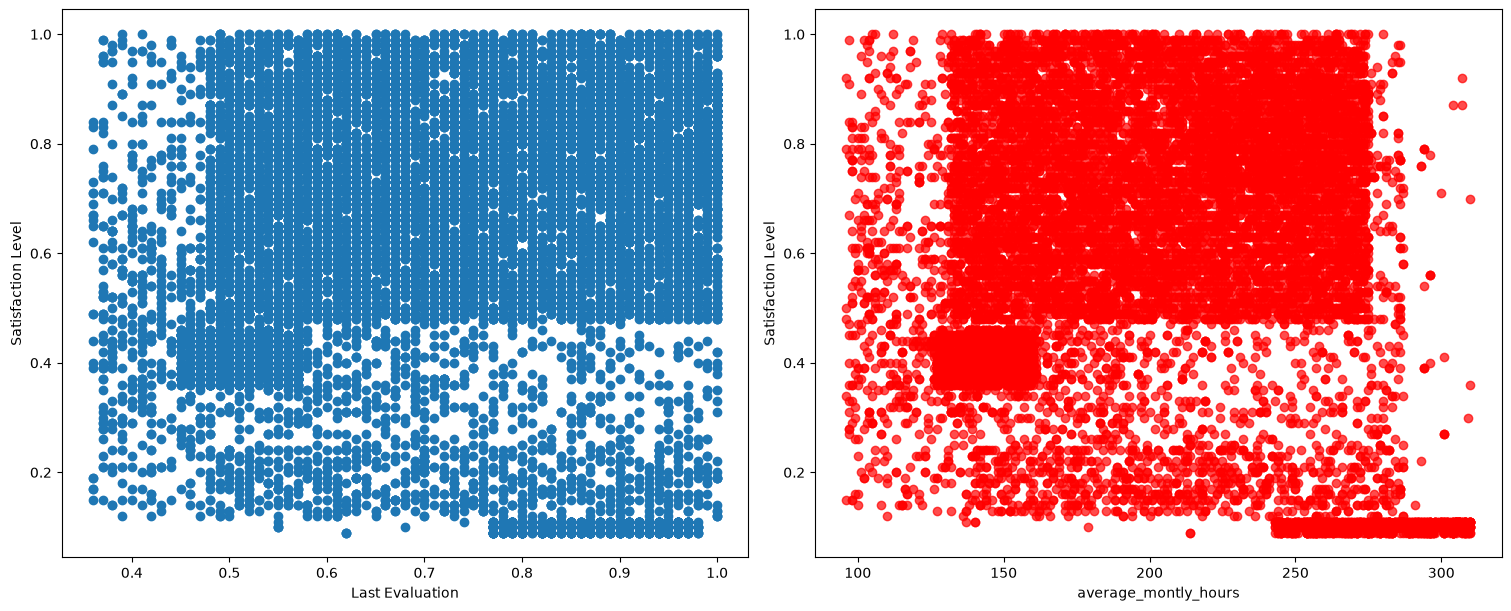

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), layout='constrained')

axs[0].scatter(X['last_evaluation'], y)
axs[0].set_xlabel('Last Evaluation')
axs[0].set_ylabel('Satisfaction Level')

axs[1].scatter(X['average_montly_hours'], y, alpha=0.7, color='red')
axs[1].set_xlabel('average_montly_hours')
axs[1].set_ylabel('Satisfaction Level')

14. Nedan ser vi en början till modellering av ett dataset kopplat till diabetes.
Läs på vad datasetet innebär och genomför ett komplett ML-flöde. Börja
med att göra ett grundläggande flöde som fungerar, därefter kan du om
du önskar försöka förbättra resultatet.

In [25]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
# This code is merely executed to see the description of the data in a smooth way
data = load_diabetes()
print(data.DESCR)
# Storing/loading the data the way it will be used
X, y = load_diabetes(return_X_y=True, as_frame=True)
print(X.info())
print(y.info())
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

15. I denna uppgift ska vi arbeta med datasetet “car_price_dataset.csv”. (Optional)

a) Gör ett komplett ML flöde där den beroende variabeln, 𝑦, är price. Vi
vill alltså skapa en modell som kan prediktera en bils pris. Ett tips är att
först göra ett enkelt flöde som fungerar, har du därefter tid kan du försöka
förbättra resultaten.

b) Gör en applikation med hjälp av Streamlit där användaren kan mata in olika uppgifter om en bil och därefter få ett predikterat pris.

c) Det du gjort i denna uppgift, hade det kunnat användas i verkligheten?
Till vad i sådana fall?

16. I denna uppgift ska du göra ett komplett ML-flöde där du modellerar diamantpriser som finns tillgängliga i datasetet “diamonds.csv”.